In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_dir = "D:/DeepSSFP/"
model_name="water_phantom_T2maps"

100%|██████████| 8/8 [00:24<00:00,  3.09s/it]


Dataset loaded: (160, 416, 416, 16)
Memory size: 0.88604672 GB
Dataset shape: (160, 416, 416, 16)
Formatting data for SyntheticBanding mode...
Data format complete.
Input shape: (160, 416, 416, 8), Output shape: (160, 416, 416, 8)
Selected indices: [33 55]
Figure size: (16, 4)


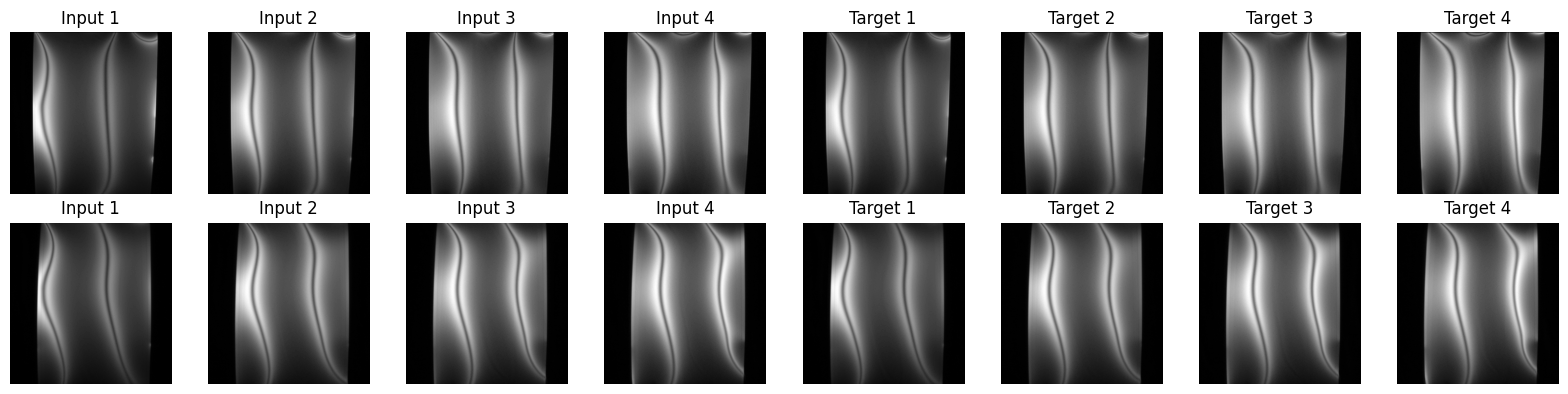

In [3]:
import deepssfp.dataloader
import deepssfp.dataformatter

path = 'D:/MRI/2025_04_23_DeepSSFP_T2_Phantom'
filters = ['grad']

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters, data_format='RealImag', 
    folder_names=['pc_0', 'pc_45', 'pc_90', 'pc_135', 'pc_180', 'pc_225', 'pc_270', 'pc_315'])
print(f"Dataset shape: {dataset['M'].shape}")
input, output = deepssfp.dataformatter.format_synthetic_banding_for_realimag_data(dataset['M'])
print(f"Input shape: {input.shape}, Output shape: {output.shape}")

deepssfp.visualize_images(
    input_images=input,
    target_images=output,
    num_samples=2,
)


===== Running experiment: SyntheticBanding =====
Model path: D:/DeepSSFP/water_phantom_T2maps_syntheticbanding
Dataset path: D:/DeepSSFP/water_phantom_T2maps_dataset.npy
Creating ds ...
Data shape: (160, 416, 416, 16)
Formatting data...
Dataset: mode:SyntheticBanding, size:160 height:416 width:416 cin:16 cout:16 ratio:0.8
dtype: float64, float64
Generating scaler... for mode: SyntheticBanding
Using same scaler for SyntheticBanding mode
Training data shape: (128, 416, 416, 16), (128, 416, 416, 16)
Input scaler stats: mean=9.0712, std=165.0301
Output scaler stats: mean=9.0712, std=165.0301
Selected indices: [16  6 22]
Figure size: (32, 6)


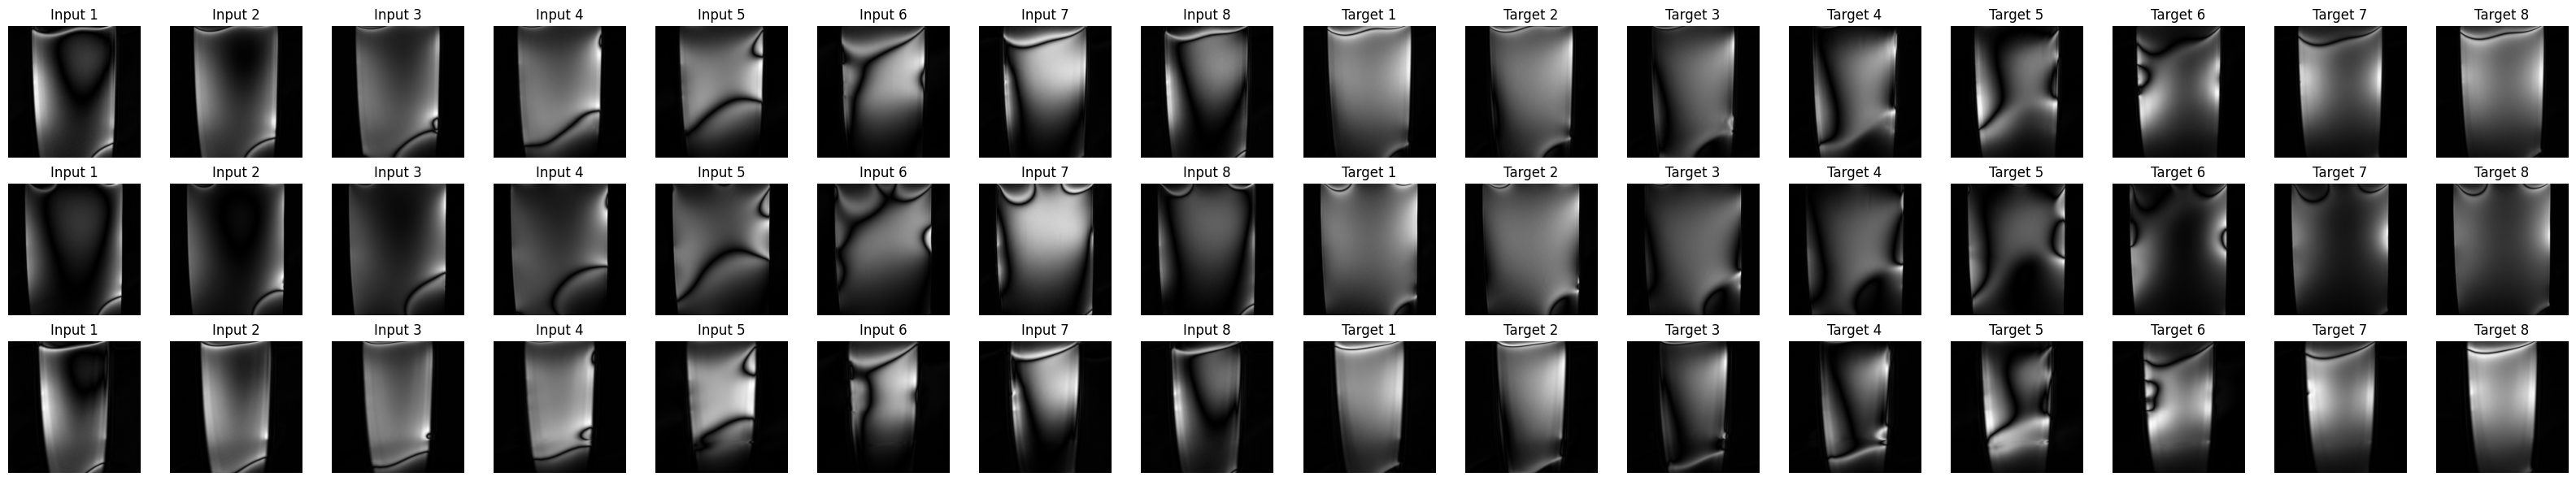

2025-04-23 23:25:58,026 - DeepSSFP - INFO - Model will be saved to: D:/DeepSSFP/water_phantom_T2maps_syntheticbanding
2025-04-23 23:25:58,026 - DeepSSFP - INFO - Training DataSet: (128, 416, 416, 16) | (128, 416, 416, 16)
2025-04-23 23:25:58,026 - DeepSSFP - INFO - Test DataSet: (32, 416, 416, 16) | (32, 416, 416, 16)
2025-04-23 23:25:58,057 - DeepSSFP - INFO - Loading existing model from D:/DeepSSFP/water_phantom_T2maps_syntheticbanding.keras



Training model...


2025-04-23 23:26:16,013 - DeepSSFP - INFO - Loading training history from D:/DeepSSFP/water_phantom_T2maps_syntheticbanding_history.npz
2025-04-23 23:26:16,106 - DeepSSFP - INFO - Continuing training from epoch 86


Model: "unet"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
img (InputLayer)                [(None, 416, 416, 16 0                                            
__________________________________________________________________________________________________
conv2d (Conv2D)                 (None, 416, 416, 32) 4640        img[0][0]                        
__________________________________________________________________________________________________
conv2d_1 (Conv2D)               (None, 416, 416, 32) 9248        conv2d[0][0]                     
__________________________________________________________________________________________________
batch_normalization (BatchNorma (None, 416, 416, 32) 128         conv2d_1[0][0]                   
_______________________________________________________________________________________________

2025-04-24 05:09:31,584 - DeepSSFP - INFO - Final model saved to D:/DeepSSFP/water_phantom_T2maps_syntheticbanding.keras


1/1 [==============================] - 1s 883ms/step - loss: 0.0511 - mean_absolute_error: 0.0913


2025-04-24 05:09:33,605 - DeepSSFP - INFO - Training Complete. Loss: 0.0511, MAE: 0.0913
2025-04-24 05:09:33,606 - DeepSSFP - INFO - Time Elapsed: 20597.49 seconds
2025-04-24 05:09:34,889 - DeepSSFP - INFO - Training history plot saved to D:/DeepSSFP/water_phantom_T2maps_syntheticbanding_training_history.png


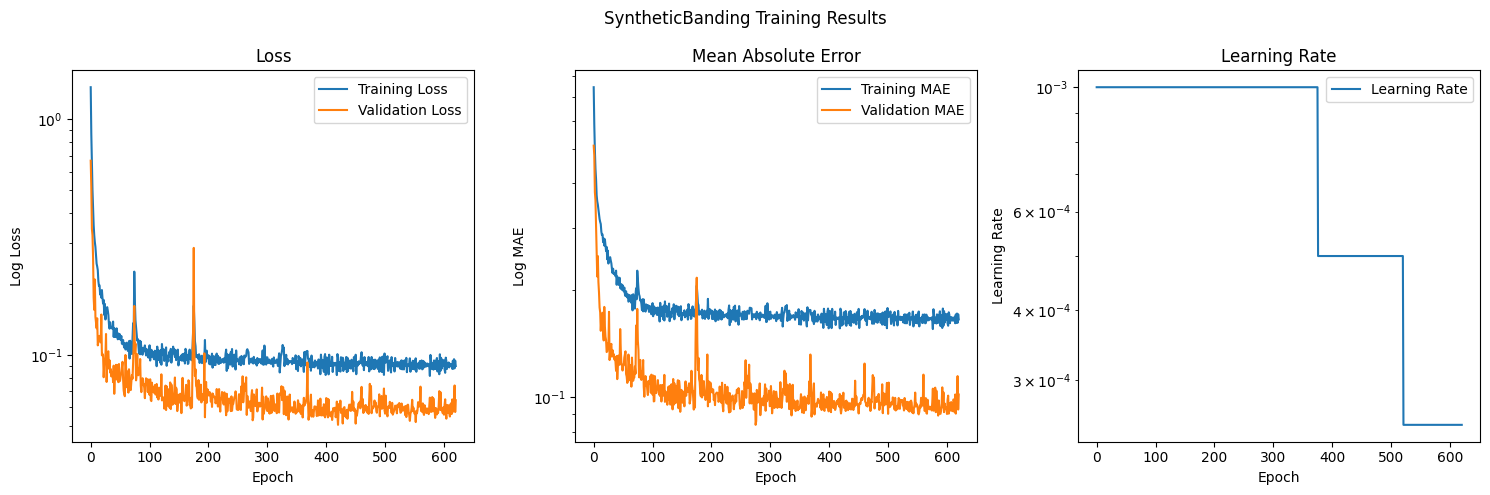

KeyError: 'seg'

In [5]:
import deepssfp.analysis
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset
)